In [1]:
!pip install pandas numpy matplotlib seaborn openpyxl


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

# Initialize directory structure for reproducibility
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

print("Directories initialized successfully.")

Directories initialized successfully.


### Selecting Relevant Columns

In [12]:
# Load the 2025 Government AI Readiness Index dataset
file_path = 'C:\\Users\\lenovo\\Desktop\\GSARP\\naari-framework\\data\\raw\\2025-Government-AI-Readiness-Index-data.xlsx'

# Load Dimensions-Pillars sheet (skipping the title row)
df_dim = pd.read_excel(file_path, sheet_name='Dimensions-Pillars', header=1)

# Define columns of interest (Macro Pillars & Sub-dimensions)
macro_cols = [
    'Ranking', 'Country', 'Total Score', 'Policy Capacity', 'AI Infrastructure', 
    'Governance', 'Public Sector Adoption', 'Development & Diffusion', 'Resilience'
]

dimension_cols = [
    'Policy vision', 'Policy commitment', 'Compute capacity', 
    'Enabling technical infrastructure', 'Data quality', 'Governance principles', 
    'Regulatory compliance', 'Government digital policy', 'e-Government delivery', 
    'Human capital', 'AI sector maturity', 'AI technology diffusion', 
    'Societal transition', 'Safety and security'
]

# Filter countries of interest (Nepal, South Asian peers, and global digital benchmarks)
key_countries = [
    'Nepal', 'India', 'Bangladesh', 'Sri Lanka', 'Pakistan', 
    'Rwanda', 'Estonia', 'Singapore', 'China', 'United States of America'
]

# Export macro scorecard results for manuscript tables
df_macro = df_dim[macro_cols].copy()
df_results_macro = df_macro[df_macro['Country'].isin(key_countries)].sort_values(by='Ranking', ascending=True).reset_index(drop=True)
df_results_macro.to_csv('../data/processed/naari_baseline_results.csv', index=False)

# Export full sub-dimension results
target_cols = macro_cols + dimension_cols
df_full_sub = df_dim[[c for c in target_cols if c in df_dim.columns]].copy()
df_results_sub = df_full_sub[df_full_sub['Country'].isin(key_countries)].sort_values(by='Ranking', ascending=True).reset_index(drop=True)
df_results_sub.to_csv('../data/processed/naari_subdimensions_results.csv', index=False)

print("Baseline data tables exported successfully to ../data/processed/")
display(df_results_macro[['Ranking', 'Country', 'Total Score']])

Baseline data tables exported successfully to ../data/processed/


,Ranking,Country,Total Score
0,1,United States of America,88.36
1,7,Singapore,76.42
2,8,China,76.27
3,21,Estonia,69.56
4,27,India,66.55
5,74,Rwanda,48.54
6,75,Bangladesh,48.37
7,80,Sri Lanka,45.60
8,81,Pakistan,45.38
9,106,Nepal,38.50


### Cumulative Stacked Bar Chart for Global Ranks

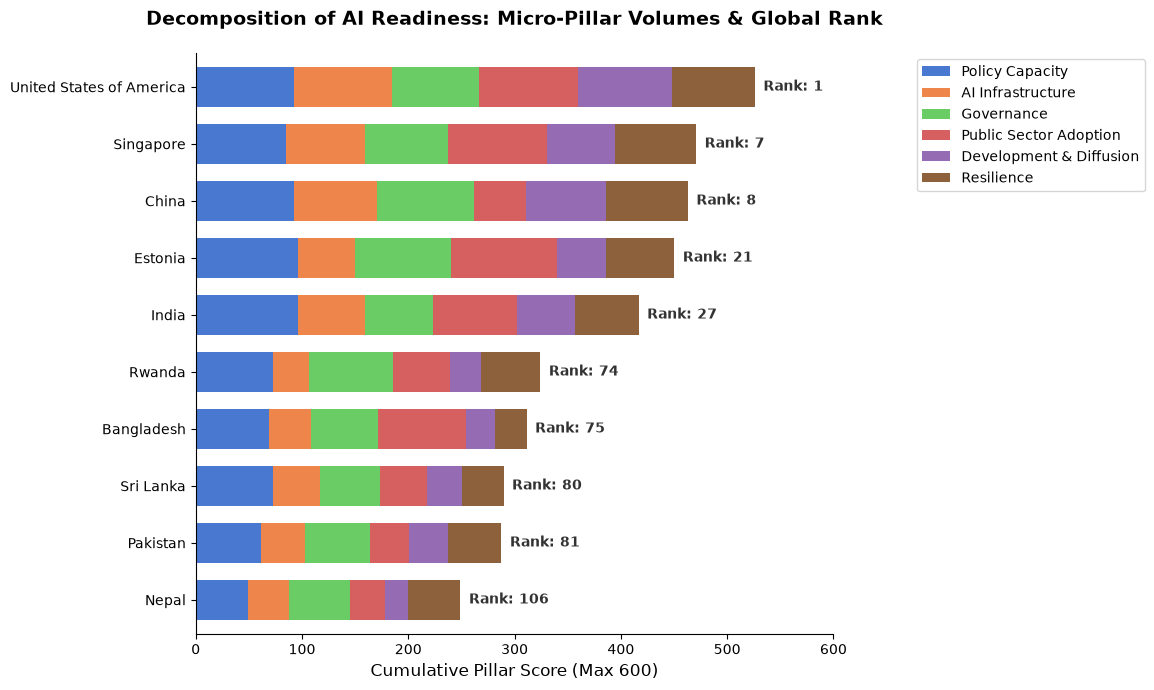

In [13]:
# Prepare subset for ranking and pillar volumes
df_subset = df_results_macro.copy().sort_values(by='Total Score', ascending=True)
categories = [
    'Policy Capacity', 'AI Infrastructure', 'Governance', 
    'Public Sector Adoption', 'Development & Diffusion', 'Resilience'
]

fig, ax = plt.subplots(figsize=(12, 7))
plot_data = df_subset.set_index('Country')[categories]
colors = sns.color_palette("muted", n_colors=6)

plot_data.plot(kind='barh', stacked=True, ax=ax, color=colors, width=0.7)

ax.set_title('Decomposition of AI Readiness: Micro-Pillar Volumes & Global Rank', fontsize=14, weight='bold', pad=20)
ax.set_xlabel('Cumulative Pillar Score (Max 600)', fontsize=12)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 600) 

# Legend placed completely outside to avoid overlapping data points
ax.legend(title='', bbox_to_anchor=(1.12, 1.0), loc='upper left', frameon=True)

# Annotate with Global Rank
for i, (idx, row) in enumerate(df_subset.iterrows()):
    rank = row['Ranking']
    tot = plot_data.loc[row['Country']].sum()
    ax.text(tot + 8, i, f"Rank: {rank}", va='center', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig("../outputs/figures/stacked_bar_with_china.png", dpi=300, bbox_inches='tight')
plt.show()

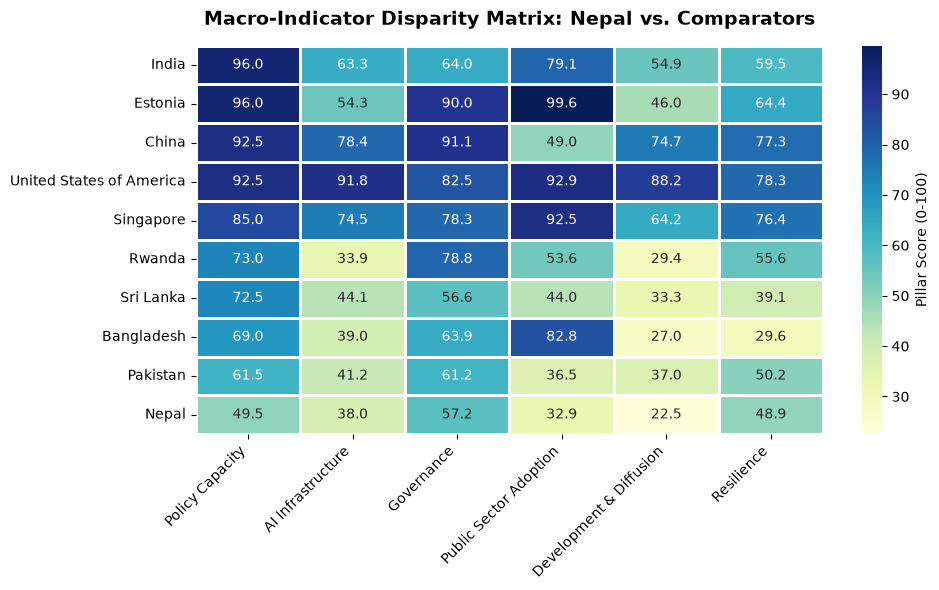

In [14]:
plt.figure(figsize=(10, 6))
heatmap_data = df_subset.set_index('Country')[categories].sort_values(by=categories[0], ascending=False)

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Pillar Score (0-100)'},
    linewidths=1,
    linecolor='white'
)

plt.title('Macro-Indicator Disparity Matrix: Nepal vs. Comparators', fontsize=14, weight='bold', pad=15)
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../outputs/figures/micro_indicator_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### Grouped Bar Chart (Pillar-by-Pillar Comparison)

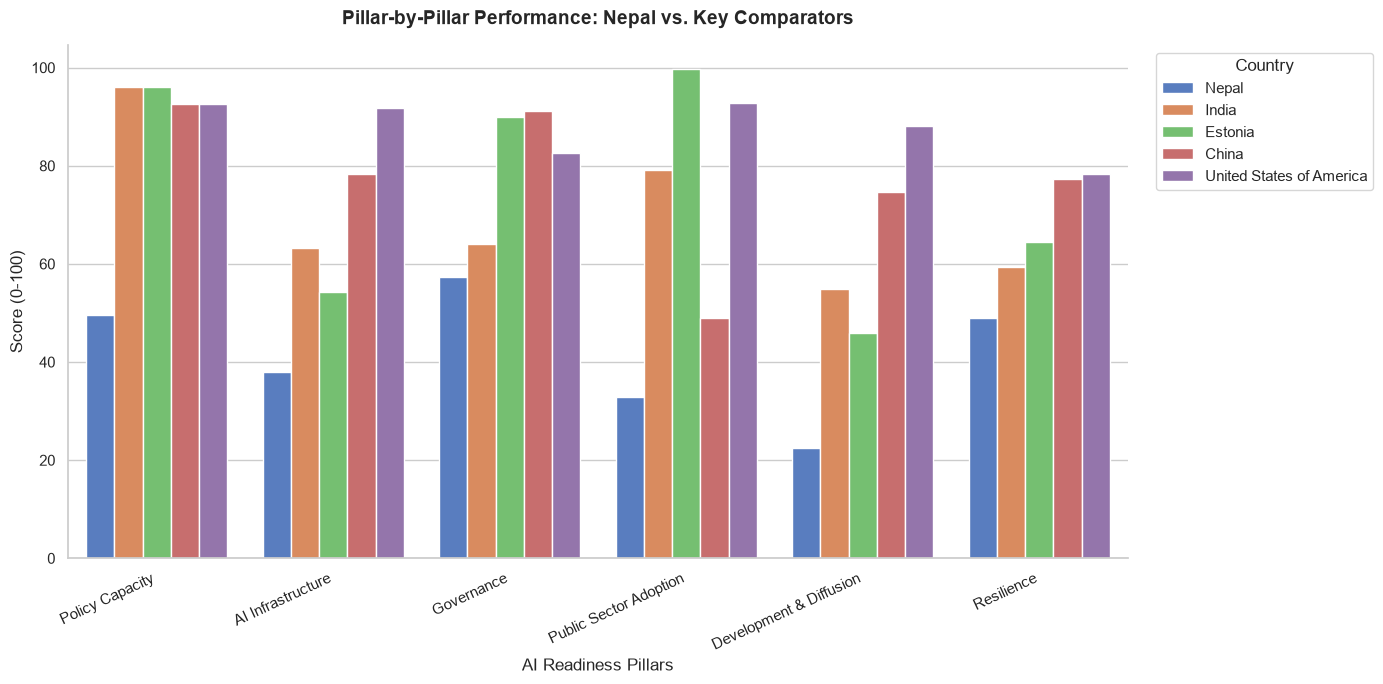

In [15]:
df_melted = df_subset.melt(id_vars=['Country', 'Ranking', 'Total Score'], 
                           value_vars=categories, 
                           var_name='Pillar', 
                           value_name='Score')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

key_countries = ['Nepal', 'India', 'China', 'United States of America', 'Estonia']
ax = sns.barplot(
    data=df_melted[df_melted['Country'].isin(key_countries)], 
    x='Pillar', 
    y='Score', 
    hue='Country',
    palette='muted'
)

plt.title('Pillar-by-Pillar Performance: Nepal vs. Key Comparators', fontsize=14, weight='bold', pad=15)
plt.xlabel('AI Readiness Pillars', fontsize=12)
plt.ylabel('Score (0-100)', fontsize=12)
plt.xticks(rotation=25, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("../outputs/figures/grouped_pillar_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

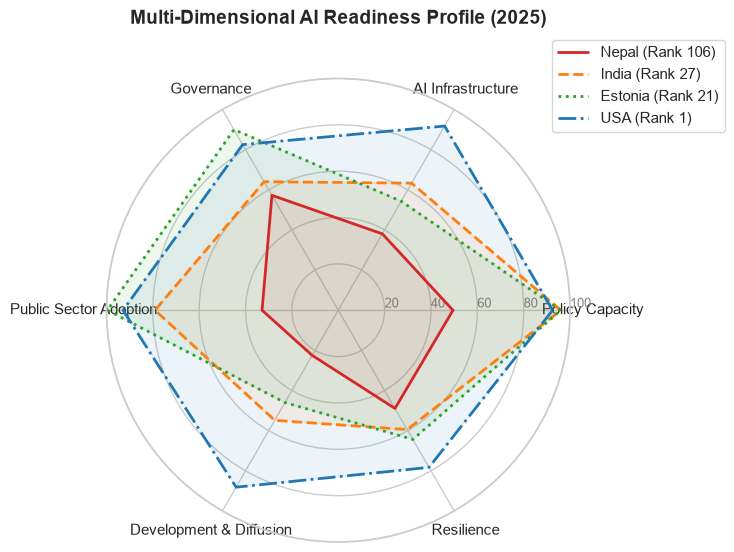

In [16]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

def add_radar_profile(country_name, label, color, linestyle='solid'):
    vals = df_subset[df_subset['Country'] == country_name][categories].values.flatten().tolist()
    vals += vals[:1]
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    ax.plot(angles, vals, linewidth=2, linestyle=linestyle, label=label, color=color)
    ax.fill(angles, vals, alpha=0.08, color=color)

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]
plt.xticks(angles[:-1], categories, size=11)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20","40","60","80","100"], color="grey", size=9)
plt.ylim(0, 100)

add_radar_profile('Nepal', 'Nepal (Rank 106)', '#d62728', 'solid')
add_radar_profile('India', 'India (Rank 27)', '#ff7f0e', 'dashed')
add_radar_profile('Estonia', 'Estonia (Rank 21)', '#2ca02c', 'dotted')
add_radar_profile('United States of America', 'USA (Rank 1)', '#1f77b4', 'dashdot')

plt.title("Multi-Dimensional AI Readiness Profile (2025)", size=14, weight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), frameon=True)
plt.tight_layout()
plt.savefig("../outputs/figures/radar_profile.png", dpi=300, bbox_inches='tight')
plt.show()

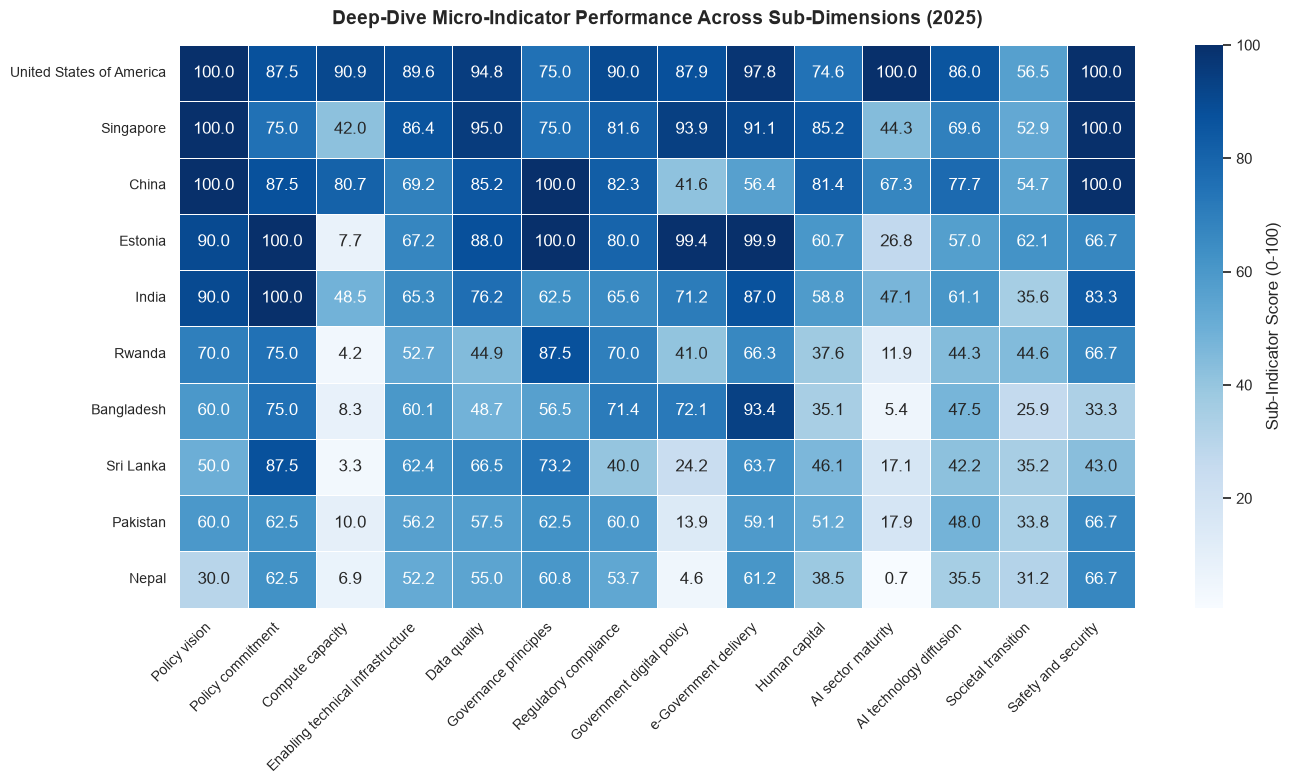

In [17]:
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

heatmap_sub = df_results_sub.set_index('Country').sort_values(by='Total Score', ascending=False)[dimension_cols]

sns.heatmap(
    heatmap_sub,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': 'Sub-Indicator Score (0-100)'}
)

plt.title('Deep-Dive Micro-Indicator Performance Across Sub-Dimensions (2025)', fontsize=14, weight='bold', pad=15)
plt.ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/figures/micro_subdimensions_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

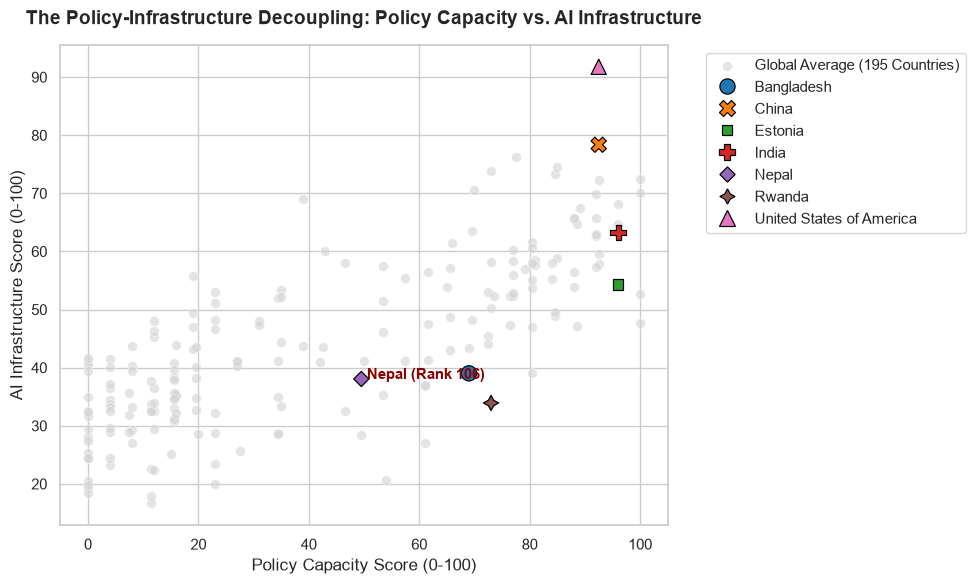

In [18]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_scatter = df_dim[['Country', 'Ranking', 'Total Score', 'Policy Capacity', 'AI Infrastructure']].copy()
df_scatter['Policy Capacity'] = pd.to_numeric(df_scatter['Policy Capacity'], errors='coerce')
df_scatter['AI Infrastructure'] = pd.to_numeric(df_scatter['AI Infrastructure'], errors='coerce')

highlight_countries = ['Nepal', 'India', 'China', 'United States of America', 'Estonia', 'Rwanda', 'Bangladesh']
df_scatter['Highlight'] = df_scatter['Country'].apply(lambda x: x if x in highlight_countries else 'Other')

sns.scatterplot(
    data=df_scatter[df_scatter['Highlight'] == 'Other'],
    x='Policy Capacity',
    y='AI Infrastructure',
    color='lightgrey',
    alpha=0.6,
    s=50,
    label='Global Average (195 Countries)'
)

sns.scatterplot(
    data=df_scatter[df_scatter['Highlight'] != 'Other'],
    x='Policy Capacity',
    y='AI Infrastructure',
    hue='Country',
    palette='tab10',
    s=120,
    style='Country',
    markers=True,
    edgecolor='black'
)

nepal_row = df_scatter[df_scatter['Country'] == 'Nepal'].iloc[0]
plt.text(nepal_row['Policy Capacity'] + 1, nepal_row['AI Infrastructure'], 'Nepal (Rank 106)', 
         fontweight='bold', color='darkred', fontsize=11)

plt.title('The Policy-Infrastructure Decoupling: Policy Capacity vs. AI Infrastructure', fontsize=14, weight='bold', pad=15)
plt.xlabel('Policy Capacity Score (0-100)', fontsize=12)
plt.ylabel('AI Infrastructure Score (0-100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig("../outputs/figures/policy_vs_infrastructure_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
import os
import pandas as pd

# 1. Ensure the processed data directory exists
os.makedirs('data/processed', exist_ok=True)

# 2. Structure the dataset extracted from the Sectoral Action Plan
sectoral_data = [
    {
        "SN": 1,
        "Sector": "Governance",
        "Focus Area": "Formulating Necessary Laws and Standards to Build a Secure and Sustainable AI Ecosystem",
        "Key Project": "Develop laws to address potential challenges to national sovereignty, territorial integrity, national interests, self-respect, and independence posed by AI while also regulating AI technology, infrastructure, human resources, and its development and application.",
        "Responsible Agency": "National AI Center, National AI Council",
        "Supporting Agency": "MoCIT, OPMCM, MoF, MoLJPA",
        "Impact": "Enhanced National Security & Sovereignty, Economic Growth & Innovation, Ethical AI Governance, Workforce Development, Sustainable AI Ecosystem"
    },
    {
        "SN": 2,
        "Sector": "Agriculture and Food Security",
        "Focus Area": "AI-powered Smart Farming: Precision agriculture using AI for weather prediction, soil health monitoring, and crop disease detection. Supply Chain Optimization: AI to reduce food waste and improve distribution channels.",
        "Key Project": "Robust Digital Infrastructure (IoT devices), Data Ecosystem Development, Skilled Workforce and Education, Research and Innovation Ecosystem.",
        "Responsible Agency": "Ministry of Agriculture and Livestock Development (implied)",
        "Supporting Agency": "Research Institutions, Private Sector",
        "Impact": "Increased crop yields through precision farming, Reduction of food waste, Enhanced resilience to climate change."
    },
    {
        "SN": 3,
        "Sector": "Education and Skill Development",
        "Focus Area": "Personalized Learning Systems: Adaptive AI-based platforms tailored to individual student needs. Virtual Classrooms: AI-driven tools for remote education.",
        "Key Project": "AI-integrated curriculums, teacher training programs, smart classrooms, AI tutoring tools.",
        "Responsible Agency": "Ministry of Education, Science, and Technology (MoEST)",
        "Supporting Agency": "Universities, Private Sector",
        "Impact": "Improved access to quality education in rural areas, Better alignment of skills with market needs, Reduction of education inequality."
    },
    {
        "SN": 4,
        "Sector": "Healthcare",
        "Focus Area": "Telemedicine Platforms: AI-powered diagnosis and consultation. Disease Prediction & Management: AI models for tracking and controlling epidemics.",
        "Key Project": "Telemedicine platforms, diagnostic AI tools, secure patient data storage and analysis, drug development acceleration.",
        "Responsible Agency": "Ministry of Health and Population (MoHP)",
        "Supporting Agency": "Hospitals, Research Institutions",
        "Impact": "Early detection and management of diseases, Expanded access to healthcare in underserved regions, Accelerated pharmaceutical research."
    },
    {
        "SN": 5,
        "Sector": "Governance and Public Services",
        "Focus Area": "E-Governance Platforms, Corruption Detection, Social Services and Poverty Alleviation, Defense and Security.",
        "Key Project": "AI-driven public service portals, corruption monitoring, targeted social welfare analytics, border management.",
        "Responsible Agency": "Department of Information Technology (DoIT), National AI Center",
        "Supporting Agency": "Relevant Ministries",
        "Impact": "Greater transparency and efficiency in public service delivery, Reduced corruption, Enhanced citizen engagement."
    },
    {
        "SN": 6,
        "Sector": "Disaster Management",
        "Focus Area": "Early Warning Systems, Resource Allocation, Environmental and Natural Resource Management.",
        "Key Project": "Deployment of sensors, predictive algorithms for flood/landslide forecasting, real-time disaster mapping via drones.",
        "Responsible Agency": "National Disaster Management Authority (NDMA), National AI Center",
        "Supporting Agency": "Ministry of Environment, Defense Bodies",
        "Impact": "Lives and property saved through early disaster warnings, More effective resource allocation, Improved resilience against natural calamities."
    },
    {
        "SN": 7,
        "Sector": "Tourism and Cultural Preservation",
        "Focus Area": "AI-Powered Virtual Tourism, Cultural Digitization.",
        "Key Project": "AI-powered virtual tour platforms, interactive travel guides, visitor data analytics, AI-driven marketing.",
        "Responsible Agency": "Ministry of Culture, Tourism, and Civil Aviation",
        "Supporting Agency": "Private tourism firms, UNESCO, Research Institutions",
        "Impact": "Increased tourism through immersive experiences, Preservation and accessibility of cultural heritage."
    },
    {
        "SN": 8,
        "Sector": "Employment and Entrepreneurship",
        "Focus Area": "AI-Enabled Job Matching Platforms, AI for Startups, Smart Factories & Industrial Automation.",
        "Key Project": "Employment matching platforms, AI startup support hubs, smart factory automation solutions, AI skills training.",
        "Responsible Agency": "Ministry of Labour, Employment, and Social Security",
        "Supporting Agency": "Private sector firms, Business incubators, Universities",
        "Impact": "Empowered entrepreneurship, Increased job creation in data science and automation, Reduced unemployment, Enhanced productivity in SMEs."
    },
    {
        "SN": 9,
        "Sector": "Urban Development and Smart Infrastructure",
        "Focus Area": "Smart Cities, Construction Monitoring, Transportation & Logistics.",
        "Key Project": "Smart traffic management systems, automated parking, urban mobility data ecosystems, AI in smart construction.",
        "Responsible Agency": "Ministry of Urban Development",
        "Supporting Agency": "Municipalities, Smart City Projects, Private Technology Firms",
        "Impact": "Improved urban living standards, Reduced traffic congestion and energy consumption, Enhanced public transport efficiency."
    },
    {
        "SN": 10,
        "Sector": "Financial Services and Inclusion",
        "Focus Area": "AI in Microfinance, Fraud Detection, AI-Powered Credit Scoring.",
        "Key Project": "AI credit scoring models, banking fraud detection & prevention systems, AI financial literacy tools.",
        "Responsible Agency": "Ministry of Finance",
        "Supporting Agency": "Central Bank, Commercial Banks, Fintech Startups",
        "Impact": "Broader access to financial services for marginalized communities, Reduced fraud, Improved financial literacy."
    },
    {
        "SN": 11,
        "Sector": "Renewable Energy",
        "Focus Area": "Energy Forecasting, Smart Grids, AI-Integrated Smart Grids.",
        "Key Project": "AI-integrated smart grids, renewable energy prediction models, public-private green energy collaborations.",
        "Responsible Agency": "Ministry of Energy",
        "Supporting Agency": "Renewable Energy Companies, Power Distribution Companies",
        "Impact": "Increased efficiency in renewable energy production, Enhanced energy management through smart grids, Support for sustainable energy transition."
    }
]

# 3. Convert to DataFrame and export to CSV
df = pd.DataFrame(sectoral_data)
csv_output_path = 'data/processed/nepal_ai_sectoral_action_plan.csv'
df.to_csv(csv_output_path, index=False)

print(f"Successfully created and verified CSV file at: {csv_output_path}")
print(f"Total rows exported: {len(df)}")

Successfully created and verified CSV file at: data/processed/nepal_ai_sectoral_action_plan.csv
Total rows exported: 11
